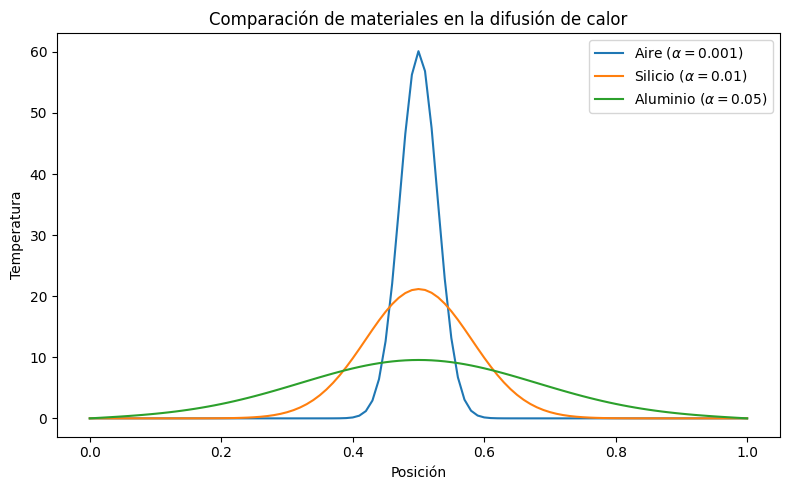

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# COMPARACION DE MATERIALES CON DIFERENTE DIFUSIVIDAD
# =====================================================

# Dominio
N = 101
L = 1.0
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Materiales
alphas = [0.001, 0.01, 0.05]
labels = ["Aire", "Silicio", "Aluminio"]

# Paso temporal estable para el mayor alpha
dt = 0.4 * dx**2 / max(alphas)

# Numero de pasos
steps = 400

plt.figure(figsize=(8, 5))

for alpha, label in zip(alphas, labels):
    T = np.zeros(N)
    center = N // 2

    # Perfil inicial distribuido
    T[center] = 100.0
    T[center - 1] = 90.0
    T[center + 1] = 95.0
    T[center - 2] = 70.0
    T[center + 2] = 75.0

    for n in range(steps):
        T_new = T.copy()
        T_new[0] = 0.0
        T_new[-1] = 0.0

        for i in range(1, N - 1):
            T_new[i] = T[i] + alpha * dt / dx**2 * (T[i + 1] - 2*T[i] + T[i - 1])

        T = T_new

    plt.plot(x, T, label=f"{label} ($\\alpha={alpha}$)")

plt.xlabel("Posición")
plt.ylabel("Temperatura")
plt.title("Comparación de materiales en la difusión de calor")
plt.legend()
plt.tight_layout()
plt.savefig("Comparacion_Materiales.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Comparacion_Materiales.pdf")